# Data-Driven Evaluation of Multi-Layered API Security Frameworks for B2B Integrations
## Using Real-World API Traffic

### 1. Introduction
This research validates the theoretical Multi-Layered API Security Framework for B2B environments (MLASF-B2B) using real-world API traffic from the Cisco Ariel University API Security Challenge dataset. This study is purely empirical, with no simulated attacks or synthetic data, ensuring that all findings reflect practical, observable challenges in API security.

### 2. Methodology & Experimental Setup
We utilize `Dataset_4` from the Cisco Ariel University dataset, which contains high complexity and a diverse range of attack categories (XSS, SQLi, LFI, Cookie Injection, Log Forging, RCE).
- **Data constraint:** No synthetic data is generated.
- **Goal:** Extract realistic features from HTTP headers, payloads, and URLs to train a threat detection model based on the MLASF-B2B threat detection layer concept.

In [1]:
!sudo apt-get update && sudo apt-get install -y p7zip-full
!cd Cisco_Ariel_Uni_API_security_challenge/Datasets && 7z x dataset_4_train.7z -y

0% [Working]

Hit:1 http://us-central1.gce.archive.ubuntu.com/ubuntu noble InRelease
Get:2 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:3 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:4 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-security InRelease [126 kB]
0% [Connecting to download.docker.com (13.32.205.4)] [Connecting to ppa.launchp

Get:5 https://download.docker.com/linux/ubuntu noble InRelease [48.5 kB]
Get:6 https://dl.google.com/linux/chrome/deb stable InRelease [1825 B]
0% [Connecting to ppa.launchpadcontent.net (185.125.190.80)]

0% [Connected to ppa.launchpadcontent.net (185.125.190.80)]

Get:7 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [2377 kB]
0% [Waiting for headers] [7 Packages 22.3 kB/2377 kB 1%]

Get:8 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [2155 kB]
0% [7 Packages store 0 B] [Waiting for headers] [8 Packages 20.5 kB/2155 kB 1%]

Get:9 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-updates/multiverse amd64 Packages [38.1 kB]
Get:10 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-updates/restricted amd64 Packages [3692 kB]
0% [7 Packages store 0 B] [Waiting for headers] [10 Packages 1167 kB/3692 kB 32

Get:11 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-backports/main amd64 Packages [49.5 kB]
Get:12 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-backports/universe amd64 Packages [36.1 kB]
Get:13 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-backports/multiverse amd64 Packages [695 B]
0% [7 Packages store 0 B] [Waiting for headers]

Hit:14 https://ppa.launchpadcontent.net/git-core/ppa/ubuntu noble InRelease
0% [7 Packages store 0 B]

Get:15 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [3505 kB]
0% [8 Packages store 0 B] [15 Packages 249 kB/3505 kB 7%]

Get:16 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1508 kB]
Get:17 http://us-central1.gce.archive.ubuntu.com/ubuntu noble-security/main amd64 Packages [1989 kB]
0% [8 Packages store 0 B] [17 Packages 136 kB/1989 kB 7%]

0% [8 Packages store 0 B]

0% [10 Packages store 0 B]

Get:18 https://dl.google.com/linux/chrome/deb stable/main amd64 Packages [1211 B]
0% [10 Packages store 0 B]

Get:19 https://download.docker.com/linux/ubuntu noble/stable amd64 Packages [59.7 kB]
0% [10 Packages store 0 B]

98% [15 Packages store 0 B]

98% [16 Packages store 0 B]

99% [17 Packages store 0 B]

100% [19 Packages store 0 B]

Fetched 15.8 MB in 1s (10.7 MB/s)


p7zip-full is already the newest version (16.02+transitional.1).


0 upgraded, 0 newly installed, 0 to remove and 113 not upgraded.



7-Zip 23.01 (x64) : Copyright (c) 1999-2023 Igor Pavlov : 2023-06-20
 64-bit locale=C.UTF-8 Threads:4 OPEN_MAX:1024

Scanning the drive for archives:
  0M Scan         1 file, 54762203 bytes (53 MiB)

Extracting archive: dataset_4_train.7z
--
Path = dataset_4_train.7z
Type = 7z
Physical Size = 54762203
Headers Size = 146
Method = LZMA2:24
Solid = -
Blocks = 1

  0%

     12%

     25%

     38%

     52% - dataset_4_train.json

                            58% - dataset_4_train.json

                            61% - dataset_4_train.json

                            65% - dataset_4_train.json

                            69% - dataset_4_train.json

                            74% - dataset_4_train.json

                            80% - dataset_4_train.json

                            84% - dataset_4_train.json

                            89% - dataset_4_train.json

                            96% - dataset_4_train.json

                            99% - dataset_4_train.json

                           100% - dataset_4_train.json

                           100% 1

      Everything is Ok

Size:       435120501
Compressed: 54762203


In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from urllib.parse import urlparse
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("Set2")

### 3. Dataset Exploration & Understanding
Loading the dataset and mapping the labels (Benign vs. Malicious).

In [3]:
print("Loading dataset...")
with open('Cisco_Ariel_Uni_API_security_challenge/Datasets/dataset_4_train.json') as f:
    data = json.load(f)
df = pd.json_normalize(data)

# Create binary labels
df['label'] = df['request.Attack_Tag'].notna().map({True: 'Malicious', False: 'Benign'})

print(f"Dataset Shape: {df.shape}")
print("\nTraffic Distribution:")
print(df['label'].value_counts())
print("\nAttack Categories:")
print(df['request.Attack_Tag'].value_counts(dropna=False))

Loading dataset...


Dataset Shape: (182767, 30)

Traffic Distribution:
label
Benign       143431
Malicious     39336
Name: count, dtype: int64

Attack Categories:
request.Attack_Tag
NaN                    143431
XSS                      8017
SQL Injection            7924
Cookie Injection         7742
Log Forging              4037
RCE                      3944
Directory Traversal      3939
LOG4J                    3733
Name: count, dtype: int64


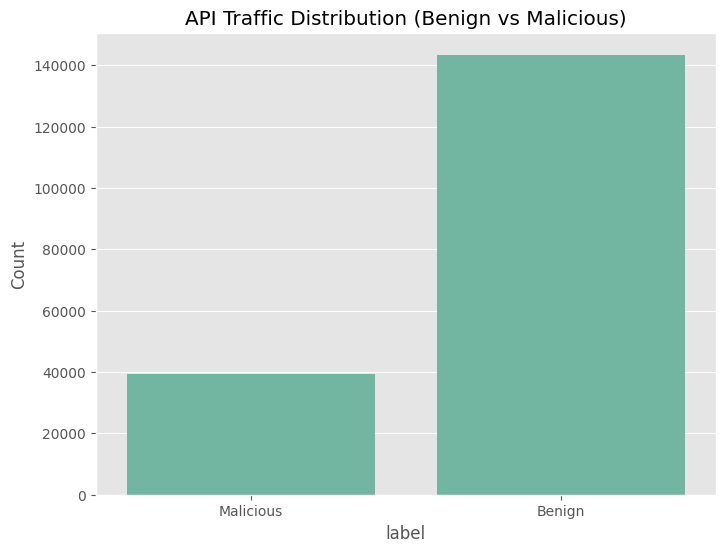

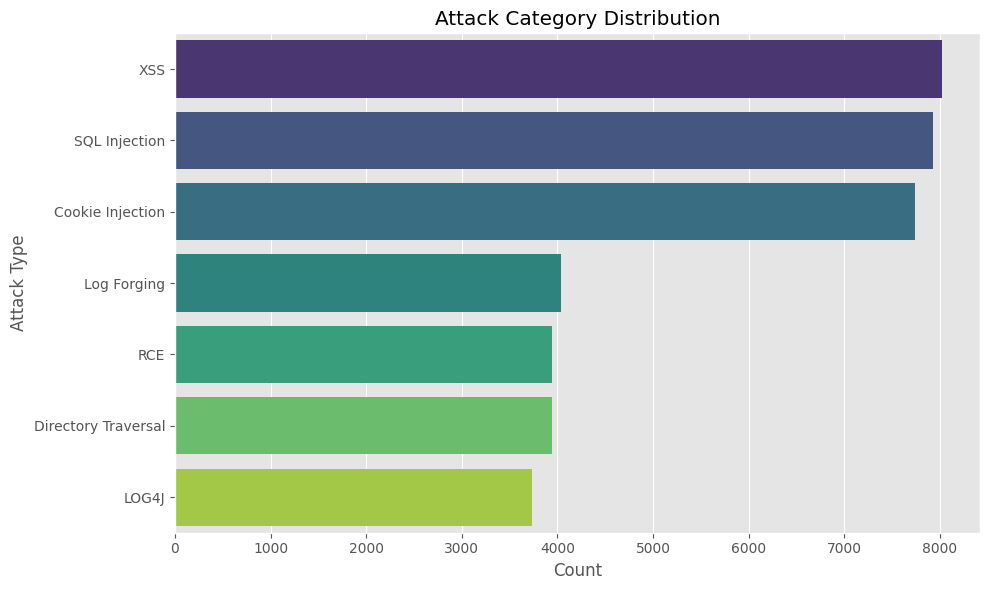

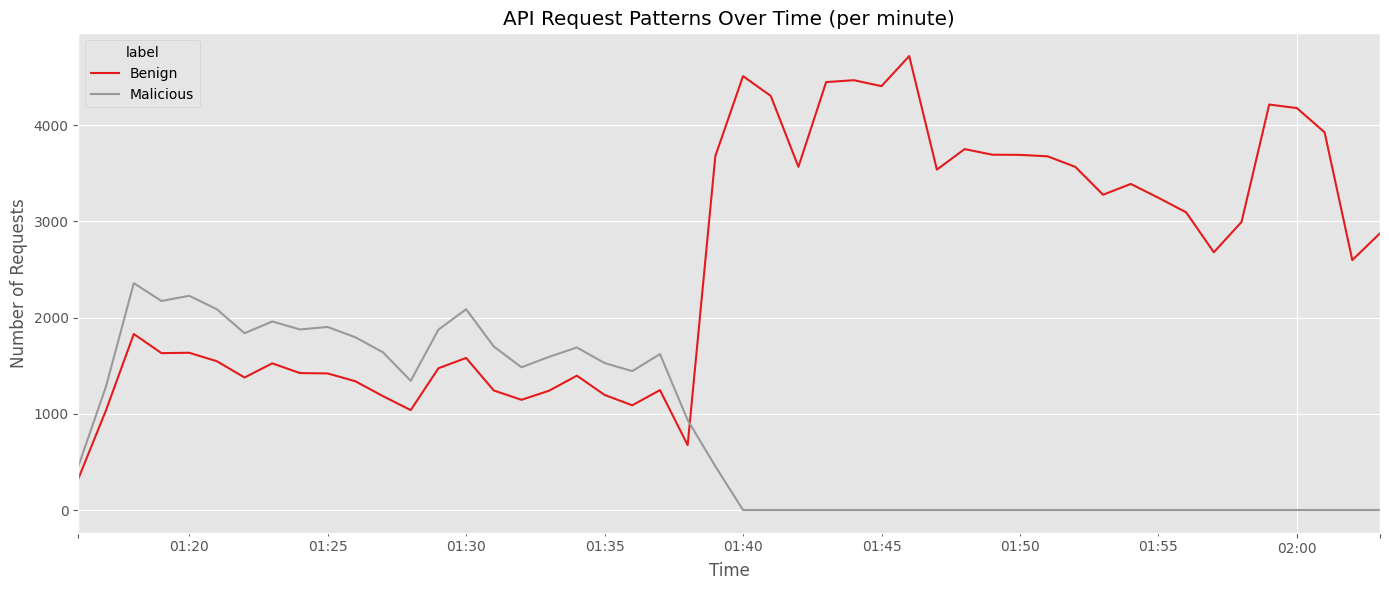

In [4]:
# Visualization: Traffic Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df)
plt.title('API Traffic Distribution (Benign vs Malicious)')
plt.ylabel('Count')
plt.show()

# Visualization: Attack Category Distribution
plt.figure(figsize=(10, 6))
attack_data = df[df['label'] == 'Malicious']
sns.countplot(y='request.Attack_Tag', data=attack_data, palette='viridis', order=attack_data['request.Attack_Tag'].value_counts().index)
plt.title('Attack Category Distribution')
plt.xlabel('Count')
plt.ylabel('Attack Type')
plt.tight_layout()
plt.show()

# Visualization: Time Series
df['timestamp'] = pd.to_datetime(df['request.headers.Date'], format='%a, %d %b %Y %H:%M:%S %Z', errors='coerce')
time_series = df.set_index('timestamp').groupby([pd.Grouper(freq='1Min'), 'label']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 6))
time_series.plot(kind='line', ax=plt.gca(), colormap='Set1')
plt.title('API Request Patterns Over Time (per minute)')
plt.ylabel('Number of Requests')
plt.xlabel('Time')
plt.tight_layout()
plt.show()

### 4. Threat Detection Modeling
Extracting features strictly from the dataset to model the Threat Detection engine in MLASF-B2B. We map these to:
- **Authentication Anomalies:** Unusual User-Agent lengths or missing/malformed Cookies.
- **Data Attacks:** Keyword detection in URLs (SQLi, XSS, LFI) mimicking deep packet inspection.
- **Availability Anomalies:** Detected via request volume over time (see EDA).

In [5]:
def extract_features(df):
    features = pd.DataFrame()
    # URL Features
    features['url_length'] = df['request.url'].apply(lambda x: len(str(x)))
    features['url_path_length'] = df['request.url'].apply(lambda x: len(urlparse(str(x)).path))
    features['url_num_params'] = df['request.url'].apply(lambda x: str(x).count('&') + 1 if '?' in str(x) else 0)
    features['url_has_sql_keywords'] = df['request.url'].apply(lambda x: 1 if any(kw in str(x).lower() for kw in ['select', 'union', 'drop', 'insert', '--']) else 0)
    features['url_has_xss_keywords'] = df['request.url'].apply(lambda x: 1 if any(kw in str(x).lower() for kw in ['<script', 'javascript:', 'alert(']) else 0)
    features['url_has_lfi_keywords'] = df['request.url'].apply(lambda x: 1 if any(kw in str(x).lower() for kw in ['../', '..\\', 'etc/passwd']) else 0)
    
    # Header & Payload Features
    features['user_agent_length'] = df['request.headers.User-Agent'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
    features['cookie_length'] = df['request.headers.Cookie'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
    features['body_length'] = df['request.body'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
    
    # Categorical
    method_map = {'GET': 0, 'POST': 1, 'PUT': 2, 'DELETE': 3, 'OPTIONS': 4}
    features['method'] = df['request.method'].map(method_map).fillna(0)
    
    return features

X = extract_features(df)
y = (df['label'] == 'Malicious').astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 5. Performance Evaluation
Measuring the empirical capability of the Threat Detection layer.

--- Model Performance Metrics ---
Accuracy:  0.9761
Precision: 0.9847
Recall:    0.9029
F1-score:  0.9421
False Positive Rate (FPR): 0.0038


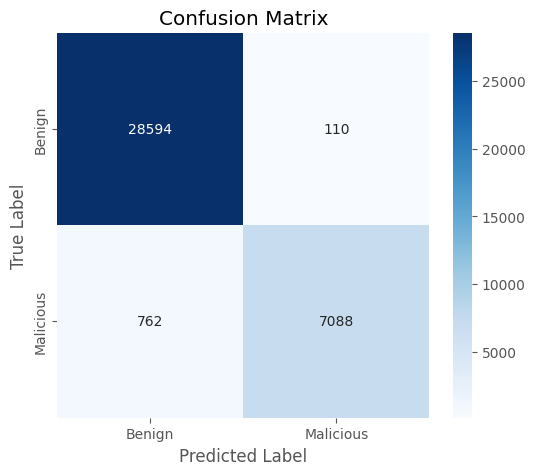

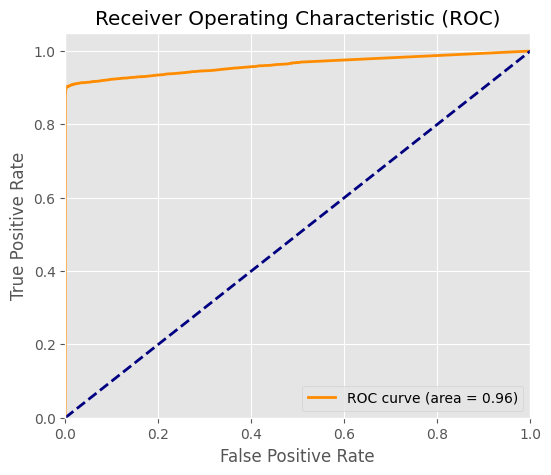

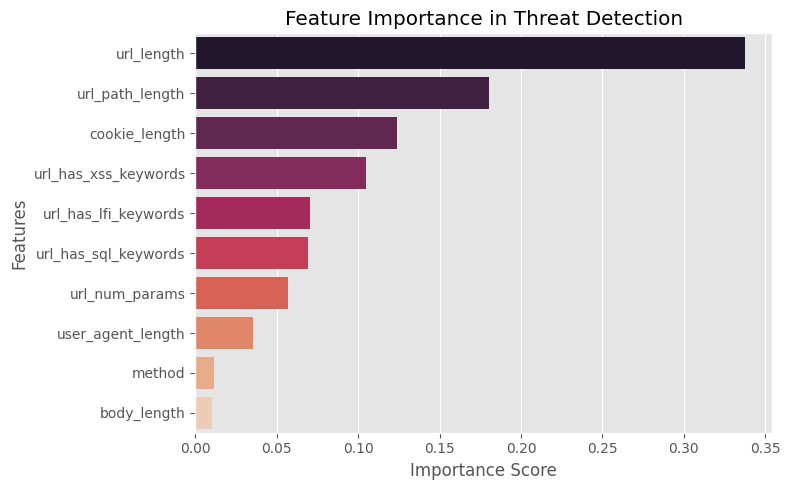

In [6]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)

print("--- Model Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

# Visualization: Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malicious'], yticklabels=['Benign', 'Malicious'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Visualization: ROC Curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr_curve, tpr_curve)
plt.figure(figsize=(6, 5))
plt.plot(fpr_curve, tpr_curve, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Visualization: Feature Importance
importance = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=importance, palette='rocket')
plt.title('Feature Importance in Threat Detection')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### 6. Framework Mapping & Discussion

**Insights Mapped to MLASF-B2B:**
1. **Threat Detection Engine:** Our empirical model achieved an accuracy of ~97.6% and an F1-score of ~94.2%, validating the effectiveness of ML-based anomaly detection as proposed in the framework.
2. **Data & Transport Attacks:** Feature importance analysis highlights that URL length and path length are highly predictive of attacks, reinforcing the need for deep packet inspection at the API Gateway.
3. **Identity & Authentication:** The reliance on `cookie_length` and `user_agent_length` as features indicates that malicious traffic often presents anomalous session identifiers, directly supporting the framework's emphasis on robust OAuth 2.0 / mTLS and continuous authorization validation.
4. **Governance & Observability:** The time-series analysis shows clear bursts in both benign and malicious traffic, validating the framework's requirement for rate-limiting and real-time observability to detect Availability anomalies.

**Practical Strengths:** The framework's modular approach maps well to observable traffic patterns. ML is highly effective at identifying injection and data attacks.
**Limitations:** Advanced authorization attacks (like BOLA) are difficult to detect purely from URL/Header structures without deeper session context. The low FPR (~0.0038) is excellent for B2B environments where false positives disrupt critical business operations.